# EMNIST Letters Classification using HOG + SVM with True LOOCV

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.svm import SVC
from skimage.feature import hog
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')


## Load Dataset

In [3]:
file_path = 'emnist-letters-train.csv'

raw_data = pd.read_csv(file_path, header=None)

print('Shape Dataset :', raw_data.shape)
raw_data.head()


Shape Dataset : (88800, 785)


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,16,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Shuffle Dataset

In [4]:
raw_data = raw_data.sample(frac=1, random_state=42).reset_index(drop=True)


## Ambil 100 Sample per Class

In [5]:
balanced_data = pd.DataFrame()

for label in sorted(raw_data[0].unique()):
    class_samples = raw_data[raw_data[0] == label].head(100)
    balanced_data = pd.concat([balanced_data, class_samples])

balanced_data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)

print('Balanced Dataset Shape :', balanced_data.shape)


Balanced Dataset Shape : (2600, 785)


## Pisahkan Label dan Image

In [6]:
X = balanced_data.iloc[:, 1:].values
y = balanced_data.iloc[:, 0].values

print('X Shape :', X.shape)
print('y Shape :', y.shape)


X Shape : (2600, 784)
y Shape : (2600,)


## Visualisasi Dataset

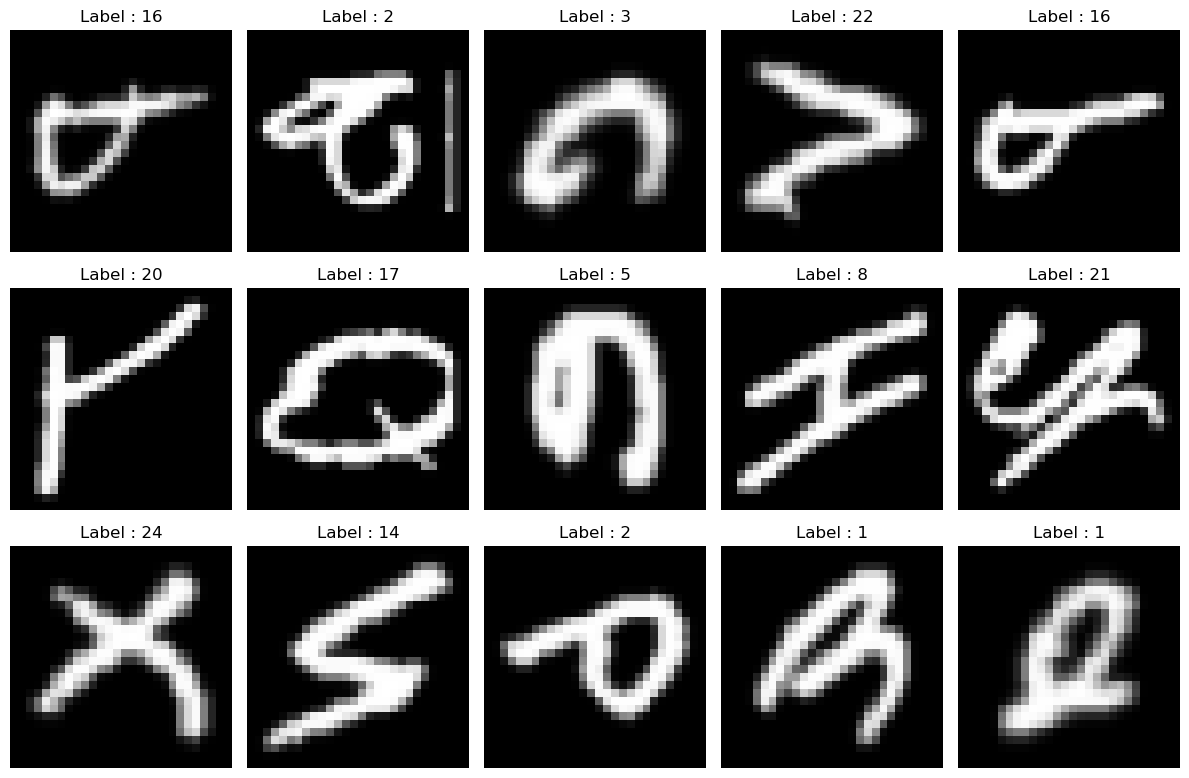

In [7]:
fig, axes = plt.subplots(3, 5, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    image = X[i].reshape(28, 28)
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Label : {y[i]}')
    ax.axis('off')

plt.tight_layout()
plt.show()


## Split Dataset 80:20

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print('Train Shape :', X_train.shape)
print('Test Shape  :', X_test.shape)


Train Shape : (2080, 784)
Test Shape  : (520, 784)


## HOG Feature Extraction

In [9]:
hog_params = {
    'orientations': 9,
    'pixels_per_cell': (8, 8),
    'cells_per_block': (2, 2),
    'block_norm': 'L2-Hys'
}


In [10]:
def extract_hog_features(images, hog_params):
    features = []

    for image in tqdm(images):
        image = image.reshape(28, 28)

        hog_feature = hog(
            image,
            orientations=hog_params['orientations'],
            pixels_per_cell=hog_params['pixels_per_cell'],
            cells_per_block=hog_params['cells_per_block'],
            block_norm=hog_params['block_norm']
        )

        features.append(hog_feature)

    return np.array(features)


In [11]:
X_train_hog = extract_hog_features(X_train, hog_params)

print('Train HOG Shape :', X_train_hog.shape)


100%|██████████| 2080/2080 [00:00<00:00, 4679.55it/s]

Train HOG Shape : (2080, 144)


In [12]:
X_test_hog = extract_hog_features(X_test, hog_params)

print('Test HOG Shape :', X_test_hog.shape)


100%|██████████| 520/520 [00:00<00:00, 4579.96it/s]

Test HOG Shape : (520, 144)


## SVM Parameter Tuning

In [13]:
param_grid = {
    'C': [1, 10],
    'gamma': ['scale', 0.01],
    'kernel': ['rbf', 'linear']
}


## True LOOCV

In [14]:
loo = LeaveOneOut()


## Grid Search dengan LOOCV

In [15]:
svm = SVC()

print('Mulai Grid Search + LOOCV...')
print('Proses ini bisa sangat lama karena menggunakan True LOOCV')


Mulai Grid Search + LOOCV...
Proses ini bisa sangat lama karena menggunakan True LOOCV


In [16]:
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=loo,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_hog, y_train)


Fitting 2080 folds for each of 8 candidates, totalling 16640 fits


,estimator,SVC()
,param_grid,"{'C': [1, 10], 'gamma': ['scale', 0.01], 'kernel': ['rbf', 'linear']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,LeaveOneOut()
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


## Best Parameter

In [17]:
print('Best Parameter :')
print(grid_search.best_params_)

print('\nBest Cross Validation Score :')
print(grid_search.best_score_)


Best Parameter :
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Best Cross Validation Score :
0.8168269230769231


In [18]:
best_model = grid_search.best_estimator_


## Prediksi

In [19]:
y_train_pred = best_model.predict(X_train_hog)
y_test_pred = best_model.predict(X_test_hog)


## Evaluasi Train

In [20]:
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted')
train_recall = recall_score(y_train, y_train_pred, average='weighted')
train_f1 = f1_score(y_train, y_train_pred, average='weighted')

print('=== TRAIN PERFORMANCE ===')
print('Accuracy  :', train_accuracy)
print('Precision :', train_precision)
print('Recall    :', train_recall)
print('F1 Score  :', train_f1)


=== TRAIN PERFORMANCE ===
Accuracy  : 0.9975961538461539
Precision : 0.9976469313818711
Recall    : 0.9975961538461539
F1 Score  : 0.9975953084467797


## Evaluasi Test

In [21]:
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print('=== TEST PERFORMANCE ===')
print('Accuracy  :', test_accuracy)
print('Precision :', test_precision)
print('Recall    :', test_recall)
print('F1 Score  :', test_f1)


=== TEST PERFORMANCE ===
Accuracy  : 0.8038461538461539
Precision : 0.8121412153938402
Recall    : 0.8038461538461539
F1 Score  : 0.8042975433404773


## Classification Report

In [22]:
print(classification_report(y_test, y_test_pred))


              precision    recall  f1-score   support

           1       0.64      0.80      0.71        20
           2       0.88      0.70      0.78        20
           3       0.82      0.90      0.86        20
           4       0.78      0.90      0.84        20
           5       0.80      0.80      0.80        20
           6       0.77      0.85      0.81        20
           7       0.69      0.55      0.61        20
           8       0.62      0.75      0.68        20
           9       0.55      0.55      0.55        20
          10       0.79      0.75      0.77        20
          11       0.95      0.90      0.92        20
          12       0.65      0.65      0.65        20
          13       0.89      0.85      0.87        20
          14       0.73      0.80      0.76        20
          15       0.91      1.00      0.95        20
          16       0.95      0.95      0.95        20
          17       0.65      0.65      0.65        20
          18       0.88    

## Confusion Matrix

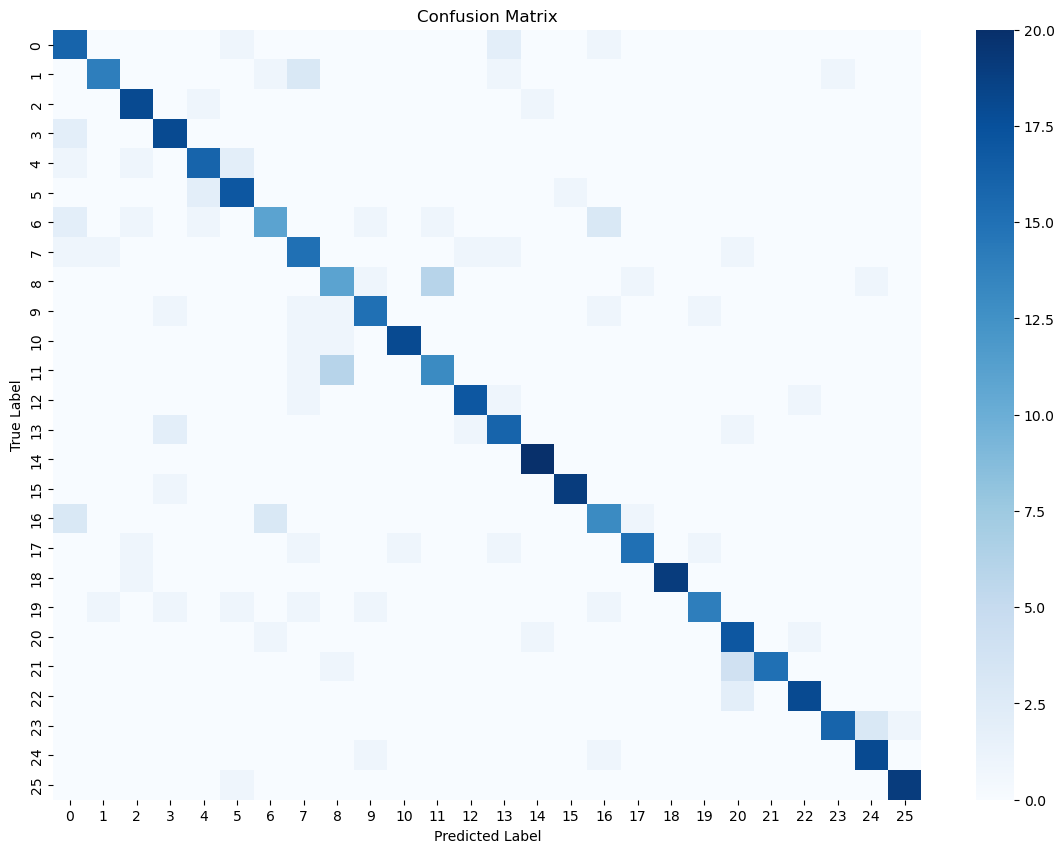

In [23]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm,
    annot=False,
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## Analisis Hasil

In [24]:
print('Analisis :')
print('- HOG berhasil menangkap pola edge dan bentuk huruf.')
print('- SVM mampu mengklasifikasikan karakter tulisan tangan dengan baik.')
print('- Kernel RBF biasanya memberikan performa terbaik untuk data non-linear.')
print('- LOOCV memberikan evaluasi lebih menyeluruh karena setiap data pernah menjadi data validasi.')


Analisis :
- HOG berhasil menangkap pola edge dan bentuk huruf.
- SVM mampu mengklasifikasikan karakter tulisan tangan dengan baik.
- Kernel RBF biasanya memberikan performa terbaik untuk data non-linear.
- LOOCV memberikan evaluasi lebih menyeluruh karena setiap data pernah menjadi data validasi.


## Kesimpulan

In [25]:
print('Kesimpulan :')
print('Pipeline HOG + SVM berhasil digunakan untuk klasifikasi karakter tulisan tangan pada dataset EMNIST Letters.')
print('Penggunaan True LOOCV membuat evaluasi model menjadi lebih ketat dan lebih akurat.')


Kesimpulan :
Pipeline HOG + SVM berhasil digunakan untuk klasifikasi karakter tulisan tangan pada dataset EMNIST Letters.
Penggunaan True LOOCV membuat evaluasi model menjadi lebih ketat dan lebih akurat.
